# Lesson165 · KumoRFM in-context relational learning

Standalone standard-library course audit. No download, API key, model training or cloud spending. Full prose and portable diagrams are embedded. Public course links work only after publication. Three live learner functions feed the complete experiment.

<div class="lab-access"><strong>Lesson package</strong> · <a href="https://avistian.github.io/relational/labs/0165-kumorfm-in-context-relational-learning.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/html/0165-kumorfm-in-context-relational-learning.html">Executed author preview</a> · <a href="https://avistian.github.io/relational/labs/solutions/0165-kumorfm-in-context-relational-learning.ipynb">Solution</a><br><a href="https://avistian.github.io/relational/reference/relational-in-context-learning.html">Quick reference</a> · <a href="https://avistian.github.io/relational/labs/l165-reproduction.md">Reproduction contract</a> · <a href="https://avistian.github.io/relational/labs/evidence/l165/report.md">Executed audit</a></div>

## 1 · Change the examples, keep the weights

**Your tangible win:** decide whether a historical label may enter a relational prompt, then explain what evidence would be needed to reproduce a proprietary model's reported score. Allow 20 minutes for the reading and trace; the notebook and written defense extend the session.

In [Lesson 164](https://avistian.github.io/relational/lessons/0164-griffin-graph-centric-rdb-fm.html), the selected Griffin transfer protocol called for fine-tuning shared weights on the target task. The full experiment stopped at its budget gate. That adaptation recipe still required optimization for a new task. Here, ask what could change a prediction **without updating those weights**. The answer is its input: examples can specify the relationship the model should use for this request.

Recall the [foundation-model scope lesson](https://avistian.github.io/relational/lessons/0161-what-is-a-foundation-model.html): adaptation is broader than gradient descent. For a function `prediction = f(weights, query, context)`, freezing `weights` leaves `query` and `context` free to change. It does not make the prediction constant. Conversely, a program that merely averages context labels has not thereby become a pretrained foundation model.

Recall: how does Griffin fine-tuning change weights, and what stays fixed in in-context inference?

A **context example** pairs an input with a known outcome. A **query example** supplies an input whose outcome must remain hidden. In relational learning, each input may contain a neighborhood of connected rows. The task is specified by which outcome the labels mean: “purchase next week” and “return an order next week” may need the same database but different labels.

## 2 · Read the actual v1 proposal

**ICL** abbreviates in-context learning: the examples enter the input while the pretrained weights stay fixed. A **rooted subgraph** is the selected neighborhood around one row being predicted. Read the diagram as two scales of context: information inside one such neighborhood, then information exchanged across labeled examples and queries.

KumoRFM v1 describes semantic-type cell encoding, row representations, a relational graph transformer, and a final transformer over context/query representations. Labels enter both attached context tables within subgraphs and the final ICL stage across subgraphs. Weights remain fixed for in-context inference. [Report §2, Eq.1 and §2.3](https://avistian.github.io/relational/labs/sources/l165/paper.pdf#page=5).

<figure class="route-figure" tabindex="0">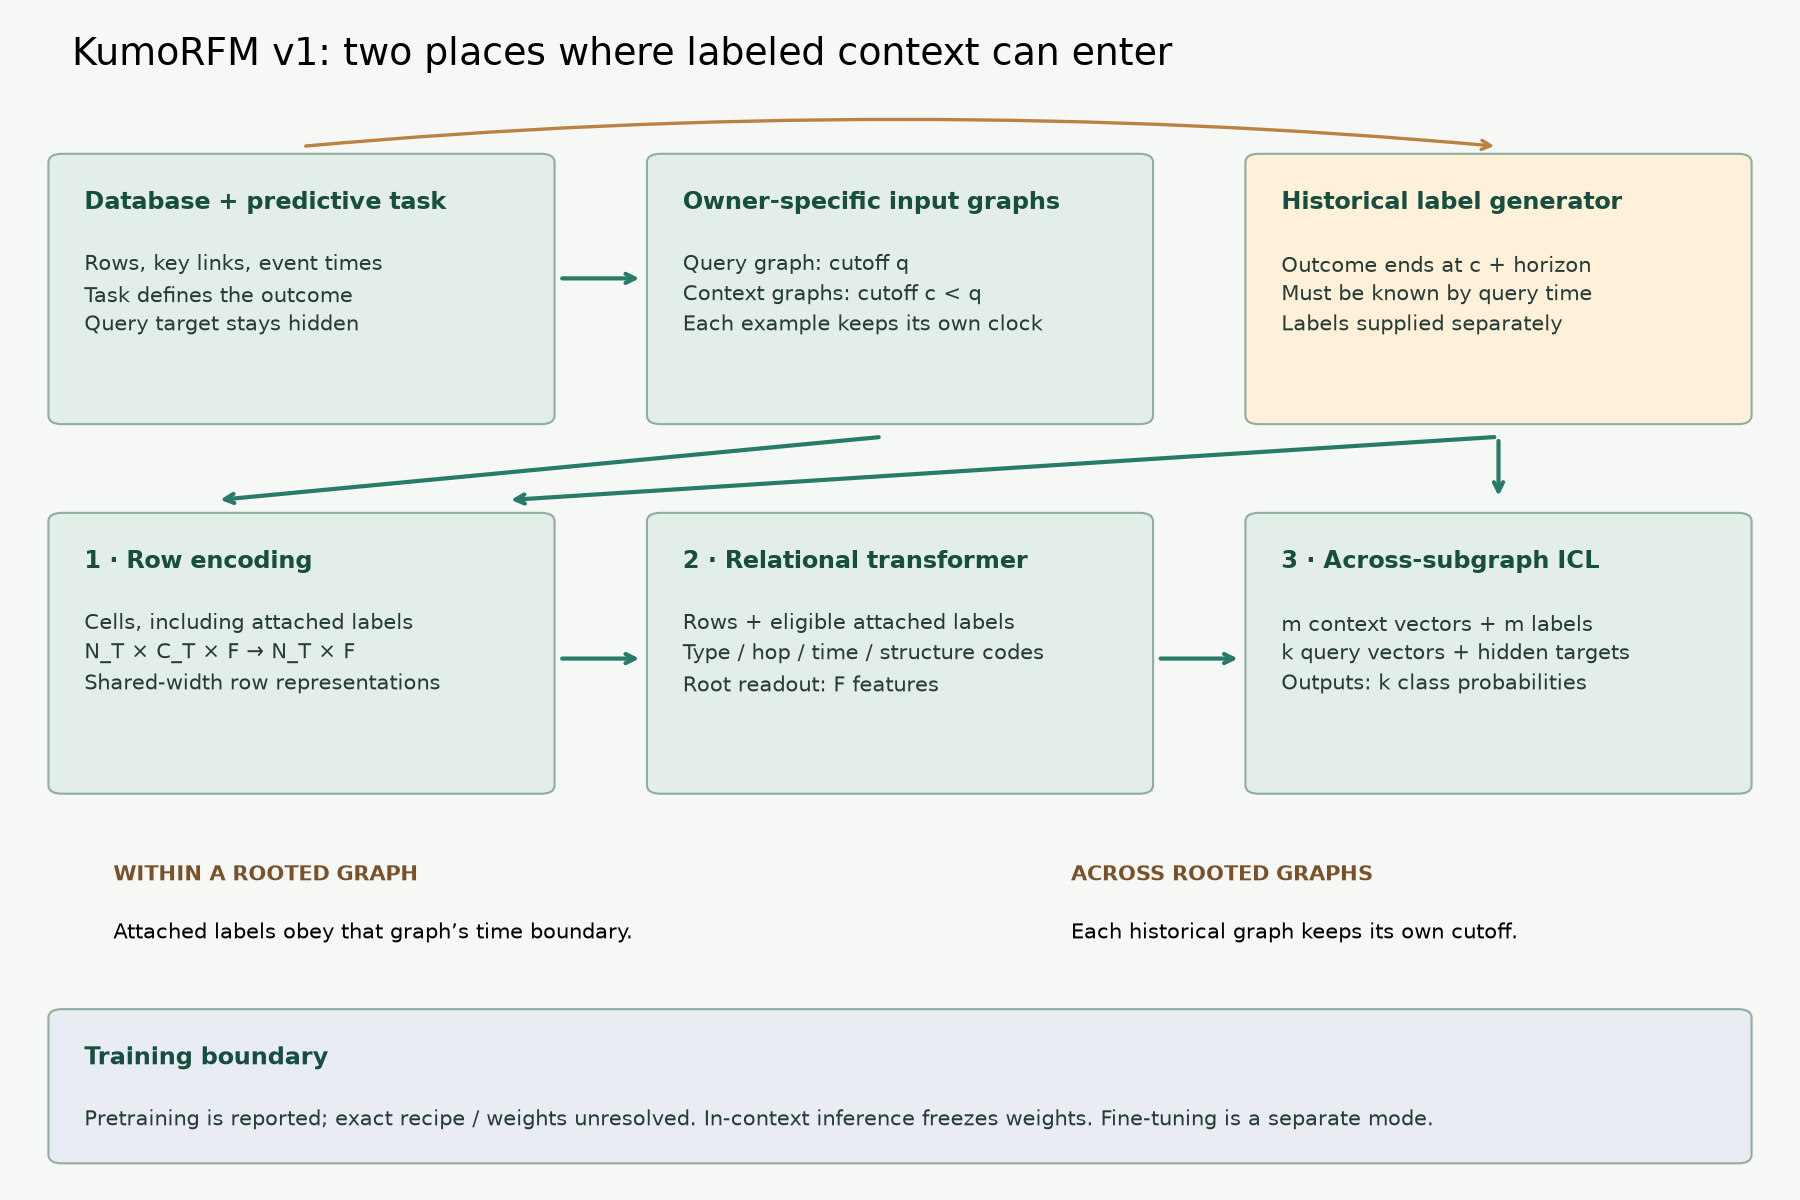<figcaption>Source-reported interfaces and information paths, not a checkpoint-compatible implementation. F is symbolic; complete masks and training configuration remain unresolved. Attached labels inside a historical graph obey that graph’s cutoff.</figcaption></figure>

**How to read the dimensions.** `N_T` counts rows in one table; `C_T` counts its columns; `F` is the shared feature width. Cell representations have shape `N_T × C_T × F`, and row representations have shape `N_T × F`. Each rooted subgraph yields a vector of width `F`. Stacking `m` examples produces `m × F`. These symbols describe interfaces; the complete numerical configuration and attention masks needed for a faithful implementation are unresolved.

The source reports mixed real/synthetic pretraining and separate fine-tuning support. It does not supply a complete reproducible pretraining recipe here. Our diagram marks that boundary rather than inventing an objective, parameter count, or training corpus. [Report §§2–2.4](https://avistian.github.io/relational/labs/sources/l165/paper.pdf#page=5).

**Within versus across.** A nearby customer's known historical outcome can be available inside a rooted graph. Separately, the representation of another entire rooted graph can be paired with its label in the final context set. These are different information paths. Neither grants permission to reveal the query's target. The notebook implements the input/evaluation contracts below; it does not implement KumoRFM's proprietary encoders or predict F1 outcomes.

## 3 · An earlier anchor does not guarantee a known label

Consider our invented customer query at day **10**. A context example is anchored at day **8**, and its label is “made a purchase over the next four days.” Its label window finishes on day **12**. Even though 8 precedes 10, the answer is not yet known. If the outcome is only recorded on day **13**, waiting until day 12 is still insufficient.

Three checks serve different purposes:

| Check | Course rule | Failure prevented |
|---|---|---|
| Earlier context | anchor < query cutoff | The query itself becoming its own example |
| Mature outcome | label-window end ≤ query cutoff | Reading an unfinished future outcome |
| Available outcome | label arrival ≤ query cutoff | Reading a completed but not yet recorded outcome |

The course assumes inclusive availability and strict earlier anchors. These are explicit teaching conventions, not a verified copy of proprietary boundary semantics. Known future schedules and corrected records would require additional availability history.

Predict before reading on: at day12, should the example whose label arrives at13 be included? Explain.

<figure class="route-figure" tabindex="0">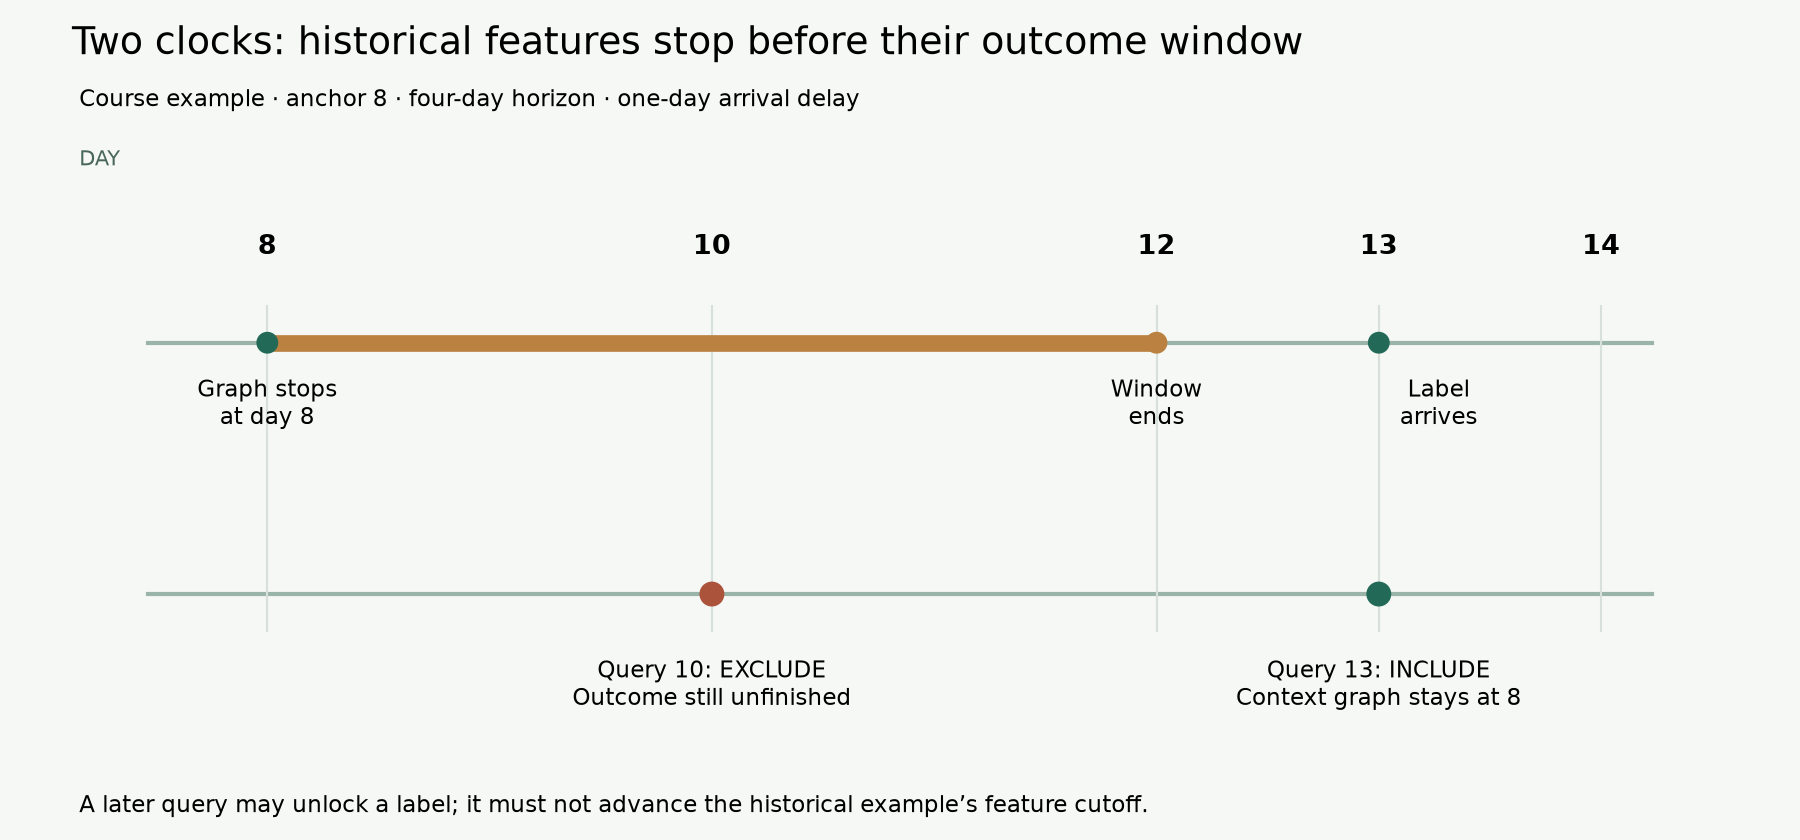<figcaption>The day-8 example is unavailable at query 10 and eligible at query 13. Its input graph remains anchored at day 8. Integer days and inclusive arrival are course conventions.</figcaption></figure>

There is a **second cutoff**. Once the day-8 example is eligible at day 13, its *input graph* must still describe what was available at day 8. Its later outcome is supplied separately as a label. Building that example's graph at day 13 would put the answer window into its features. The current query's graph, meanwhile, uses its own day-13 cutoff.

If attached context labels appear inside a historical input subgraph, they must also be available at that subgraph's cutoff. Our lab keeps labels in a separate explicit context list and does not reconstruct that attachment operator. This is a useful limit to state before treating a local temporal check as whole-system safety.

Static trace: anchor8, horizon4, delay1. At query10 or12 exclude; at13 include. Context graph cutoff stays8. Changing hidden query label cannot change inputs.

**Try it:** move query time from 10 to 12 to 13; then shorten the horizon or change the arrival delay. State which condition changed before inspecting feedback. The baseline remains visible. Query-target changes must not alter the eligible input packet.

## 4 · Make the contracts executable

You implement three small but consequential functions in the notebook. Their outputs feed the complete local audit; they are not isolated fill-in-the-blank exercises.

`eligible_context(context, query)` requires earlier anchors, mature outcomes and arrived labels. It rejects duplicate `(entity, cutoff)` keys. For query day 10, the day-2 example with end 5 and arrival 6 is legal; the day-8/end-12/arrival-13 example is not. Two different times for the same entity are distinct examples.

`visible_graph(rows, edges, root, cutoff, hops)` removes unavailable rows **before** following edges. In the invented chain `u1 — o1 — p1`, `o1` arrives at 5 and `p1` at 8. At cutoff 7, two hops can reach `o1` but cannot reach `p1`. Combining that owner with a later query in a batch must not silently raise its cutoff. The function accepts only IDs and clocks, so injecting a target-label field is rejected. Real graph features need a richer audited schema.

`keyed_auc(truth, predictions)` aligns complete keys and gives tied positive/negative scores half credit. It rejects missing, extra or duplicated queries, invalid labels and nonfinite scores. Predictions may arrive in any order.

**Worked metric.** Positives score 0.8 and 0.9; negatives score 0.8 and 0.1. The four positive–negative comparisons contribute 0.5, 1, 1, 1. Their average is **0.875**. These four scores were invented to exercise ties; no model produced them. Comparing 0.875 with the paper's score would be meaningless.

**Executed author audit:** all 144 context cases, 96 graph cases and 24 score orderings completed. Two hidden-label interventions leave inputs identical. Independent checks cover 1,134 tie-aware AUROC cases. These are deterministic synthetic contracts, not measured KumoRFM performance. [Full results](https://avistian.github.io/relational/labs/evidence/l165/report.json).

The checks deliberately reject three wrong solutions: accepting every earlier anchor, using a later cutoff for everyone, and returning a constant AUROC. The oracle also enumerates paths and compares score pairs directly, rather than relying solely on the same implementation that generated the report.

## 5 · A reported comparator is not an empirical ceiling

Our selected historical target is **Table 2, rel-f1 / driver-dnf, in-context: 82.41 AUROC**, or **0.8241** on a 0–1 scale. The fine-tuned column is a different experiment. [Original report, Table 2](https://avistian.github.io/relational/labs/sources/l165/paper.pdf#page=11).

Treat this as an author-reported comparator. Calling it a “ceiling” would imply an upper bound that no model can exceed; a published score establishes no such bound. Likewise, “zero-shot” in this setting does not mean “no labeled examples”: distinguish absence of target-task weight updates from absence of context labels.

**What prevents historical reproduction here?** Matching v1 weights and executable inference, exact test-data identity, context sampling settings and keys, seeds, and prediction artifacts remain unresolved. Our [protocol ledger](https://avistian.github.io/relational/labs/l165-reproduction.md) records each gap. A new service response could test today's service, but without an identity link it cannot reproduce this historical table cell.

Source drift is observable: the original report URL redirects to modern documentation; that documentation's paper link points to KumoRFM-2. The previously indexed mirror also returned 404 on direct retrieval. We recovered the original report from an archive and pinned its bytes. The failed repository lookup is an observation about one endpoint, not proof that no model release exists anywhere. [Retrieval ledger](https://avistian.github.io/relational/labs/sources/l165/source-ledger.json).

Thus the complete local audit and historical reproduction have different statuses: local contracts **complete**; historical experiment **NOT_RUN**; historical fidelity **NOT_ESTABLISHED**. No paid API evaluation is hidden inside the notebook. The approved budget is $0 cloud/API and at most 30 minutes of aggregate local execution.

## 6 · Defend one concrete prediction boundary

Use the [capability note template](https://avistian.github.io/relational/labs/l165-capability-template.md). Write 400–600 words and a four-row claim/evidence table. Explain the day-8/day-13 example, distinguish the two context paths, and name what must be obtained before running the historical experiment. Propose a matched evaluation without claiming the missing evidence exists.

Explain fixed weights, the two context paths, both time boundaries, and the missing v1 reproduction evidence.

Before your next session, retrieve from memory: why can fixed weights adapt; why is an earlier timestamp insufficient; why are both entity and cutoff required for scoring? Revisit these questions after three days. Code completion does not score the written defense: learner status remains **PENDING_WRITTEN_DEFENSE** until reviewed.

**Primary reading:** [Fey et al., original KumoRFM v1 report](https://avistian.github.io/relational/labs/sources/l165/paper.pdf), Eq.1, §§2.2–2.3 and Table 2. Read the mechanism first; then audit which parts of the result could be independently checked. [Lesson 166](https://avistian.github.io/relational/lessons/0166-rdb-pfn-synthetic-relational-priors.html) moves to RDB-PFN: how synthetic relational tasks train reusable weights, and what released checkpoints let us verify. The optional OpenRFM comparison is not a prerequisite for that lesson.

Ask the teaching agent about any unclear step, or submit your note for a challenge on its assumptions. A useful follow-up is: “Give me a late-arriving-label counterexample and check my context selection.”


In [1]:
# @colab-bootstrap — Python3.10+ standard library only.
from pathlib import Path
import json,hashlib

## PROVIDED · Complete deterministic input packet
All fixtures are invented course inputs, not F1 records. Exact bytes are checked before use.

In [2]:
fixture_text='{\n  "scope": "SYNTHETIC_CONTRACT_AUDIT",\n  "context_cases": [\n    {\n      "id": "a0-h0-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 0,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h0-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 0,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h0-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 0,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h0-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 0,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h0-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 2,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h0-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 2,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h0-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 2,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h0-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 2,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h0-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h0-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h0-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h0-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 0,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h3-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 3,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h3-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 3,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h3-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 3,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h3-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 3,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h3-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h3-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h3-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h3-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 5,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h3-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h3-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h3-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h3-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 3,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h7-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h7-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h7-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h7-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h7-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h7-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h7-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h7-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a0-h7-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a0-h7-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a0-h7-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a0-h7-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 0,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h0-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 4,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h0-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 4,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h0-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 4,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h0-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 4,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h0-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 6,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h0-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 6,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h0-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 6,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h0-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 6,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h0-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h0-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h0-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h0-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 4,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h3-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h3-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h3-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h3-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 7,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h3-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h3-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h3-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h3-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 9,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h3-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h3-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h3-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h3-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 7,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h7-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h7-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h7-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h7-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h7-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h7-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h7-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h7-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a4-h7-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a4-h7-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a4-h7-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a4-h7-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 4,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h0-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h0-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h0-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h0-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 8,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h0-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h0-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h0-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h0-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h0-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h0-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h0-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h0-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 8,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h3-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h3-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h3-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h3-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 11,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h3-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h3-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h3-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h3-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h3-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h3-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h3-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h3-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 11,\n          "available_at": 16,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h7-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h7-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h7-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h7-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h7-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h7-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h7-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h7-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a8-h7-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 20,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a8-h7-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 20,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a8-h7-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 20,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a8-h7-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 8,\n          "label_end": 15,\n          "available_at": 20,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h0-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h0-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h0-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h0-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 10,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h0-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h0-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h0-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h0-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 12,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h0-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h0-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h0-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h0-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 10,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h3-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h3-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h3-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h3-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 13,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h3-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h3-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h3-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h3-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 15,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h3-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 18,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h3-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 18,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h3-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 18,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h3-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 13,\n          "available_at": 18,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h7-d0-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h7-d0-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h7-d0-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h7-d0-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 17,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h7-d2-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 19,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h7-d2-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 19,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h7-d2-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 19,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h7-d2-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 19,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    },\n    {\n      "id": "a10-h7-d5-q5",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 22,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 5\n      }\n    },\n    {\n      "id": "a10-h7-d5-q10",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 22,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 10\n      }\n    },\n    {\n      "id": "a10-h7-d5-q12",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 22,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 12\n      }\n    },\n    {\n      "id": "a10-h7-d5-q16",\n      "context": [\n        {\n          "entity": "u1",\n          "cutoff": 10,\n          "label_end": 17,\n          "available_at": 22,\n          "label": 1\n        }\n      ],\n      "query": {\n        "entity": "u1",\n        "cutoff": 16\n      }\n    }\n  ],\n  "graph_cases": [\n    {\n      "id": "q4-h0-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h0-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h0-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h0-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h0-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h0-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h0-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h0-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 0\n    },\n    {\n      "id": "q4-h1-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h1-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h1-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h1-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h1-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h1-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h1-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h1-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 1\n    },\n    {\n      "id": "q4-h2-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q4-h2-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q4-h2-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q4-h2-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q4-h2-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q4-h2-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q4-h2-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q4-h2-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 4,\n      "hops": 2\n    },\n    {\n      "id": "q7-h0-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h0-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h0-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h0-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h0-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h0-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h0-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h0-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 0\n    },\n    {\n      "id": "q7-h1-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h1-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h1-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h1-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h1-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h1-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h1-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h1-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 1\n    },\n    {\n      "id": "q7-h2-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q7-h2-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q7-h2-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q7-h2-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q7-h2-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q7-h2-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q7-h2-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q7-h2-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 7,\n      "hops": 2\n    },\n    {\n      "id": "q10-h0-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h0-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h0-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h0-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h0-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h0-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h0-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h0-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 0\n    },\n    {\n      "id": "q10-h1-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h1-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h1-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h1-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h1-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h1-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h1-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h1-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 1\n    },\n    {\n      "id": "q10-h2-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q10-h2-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q10-h2-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q10-h2-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q10-h2-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q10-h2-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q10-h2-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q10-h2-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 10,\n      "hops": 2\n    },\n    {\n      "id": "q15-h0-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h0-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h0-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h0-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h0-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h0-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h0-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h0-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 0\n    },\n    {\n      "id": "q15-h1-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h1-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h1-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h1-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h1-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h1-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h1-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h1-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 1\n    },\n    {\n      "id": "q15-h2-e0",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    },\n    {\n      "id": "q15-h2-e1",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    },\n    {\n      "id": "q15-h2-e2",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    },\n    {\n      "id": "q15-h2-e3",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    },\n    {\n      "id": "q15-h2-e4",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    },\n    {\n      "id": "q15-h2-e5",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    },\n    {\n      "id": "q15-h2-e6",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    },\n    {\n      "id": "q15-h2-e7",\n      "rows": [\n        {\n          "id": "u1",\n          "event_at": null,\n          "available_at": 0\n        },\n        {\n          "id": "o1",\n          "event_at": 5,\n          "available_at": 5\n        },\n        {\n          "id": "p1",\n          "event_at": null,\n          "available_at": 8\n        },\n        {\n          "id": "o2",\n          "event_at": 12,\n          "available_at": 14\n        }\n      ],\n      "edges": [\n        [\n          "u1",\n          "o1"\n        ],\n        [\n          "o1",\n          "p1"\n        ],\n        [\n          "u1",\n          "o2"\n        ]\n      ],\n      "root": "u1",\n      "cutoff": 15,\n      "hops": 2\n    }\n  ],\n  "score_cases": [\n    {\n      "id": "permutation-00",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        }\n      ]\n    },\n    {\n      "id": "permutation-01",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        }\n      ]\n    },\n    {\n      "id": "permutation-02",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        }\n      ]\n    },\n    {\n      "id": "permutation-03",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-04",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        }\n      ]\n    },\n    {\n      "id": "permutation-05",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-06",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        }\n      ]\n    },\n    {\n      "id": "permutation-07",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        }\n      ]\n    },\n    {\n      "id": "permutation-08",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        }\n      ]\n    },\n    {\n      "id": "permutation-09",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-10",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        }\n      ]\n    },\n    {\n      "id": "permutation-11",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-12",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        }\n      ]\n    },\n    {\n      "id": "permutation-13",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-14",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        }\n      ]\n    },\n    {\n      "id": "permutation-15",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-16",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-17",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-18",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        }\n      ]\n    },\n    {\n      "id": "permutation-19",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-20",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        }\n      ]\n    },\n    {\n      "id": "permutation-21",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-22",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        }\n      ]\n    },\n    {\n      "id": "permutation-23",\n      "truth": [\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "label": 0\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "label": 1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "label": 0\n        }\n      ],\n      "predictions": [\n        {\n          "entity": "u2",\n          "cutoff": 2,\n          "score": 0.1\n        },\n        {\n          "entity": "u2",\n          "cutoff": 1,\n          "score": 0.9\n        },\n        {\n          "entity": "u1",\n          "cutoff": 2,\n          "score": 0.8\n        },\n        {\n          "entity": "u1",\n          "cutoff": 1,\n          "score": 0.8\n        }\n      ]\n    }\n  ],\n  "mask_case": {\n    "query": {\n      "entity": "u1",\n      "cutoff": 10\n    },\n    "context": [\n      {\n        "entity": "u1",\n        "cutoff": 2,\n        "label_end": 5,\n        "available_at": 6,\n        "label": 1\n      }\n    ]\n  }\n}\n'
assert hashlib.sha256(fixture_text.encode()).hexdigest()=='1f59987fb83fb70e031e26534f8e6c9fbf2bca5a108708ddd2c0fc3fafb73f4a'
packet=json.loads(fixture_text)

## TODO · eligible_context

**Goal:** Select historical labels that are both mature and available.

**Contract:** Input: list of records with exactly entity (nonempty trimmed string), cutoff, label_end, available_at (integer times, excluding bool), label (integer0/1); query exactly entity/cutoff. Require label_end≥cutoff and available_at≥label_end; reject duplicate full keys. Select cutoff<query.cutoff, label_end≤query.cutoff and available_at≤query.cutoff. Return copies sorted by (cutoff,entity), without mutating inputs. Reject invalid inputs with ValueError.

Predict one boundary case before writing code.

In [3]:
def eligible_context(context, query):
    """Select mature, arrived labels without admitting the query's target."""
    def valid_time(x):
        return type(x) is int
    def valid_entity(x):
        return isinstance(x,str) and bool(x) and x.strip()==x
    if (not isinstance(query,dict) or set(query)!={'entity','cutoff'} or
        not valid_entity(query['entity']) or not valid_time(query['cutoff'])):
        raise ValueError('query requires canonical entity and integer cutoff')
    if not isinstance(context,list):
        raise ValueError('context must be a list')
    seen=set(); selected=[]
    for row in context:
        if (not isinstance(row,dict) or set(row)!={'entity','cutoff','label_end','available_at','label'} or
            not valid_entity(row['entity']) or
            not all(valid_time(row[k]) for k in ['cutoff','label_end','available_at']) or
            type(row['label']) is not int or row['label'] not in [0,1] or
            row['label_end']<row['cutoff'] or row['available_at']<row['label_end']):
            raise ValueError('invalid context record or inconsistent label clock')
        key=(row['entity'],row['cutoff'])
        if key in seen:
            raise ValueError('duplicate context key')
        seen.add(key)
        if (row['cutoff']<query['cutoff'] and row['label_end']<=query['cutoff'] and
            row['available_at']<=query['cutoff']):
            selected.append(dict(row))
    return sorted(selected,key=lambda r:(r['cutoff'],r['entity']))

In [4]:
# CHECK
r=dict(entity="u",cutoff=8,label_end=12,available_at=13,label=1)
assert eligible_context([r],dict(entity="q",cutoff=12))==[]
assert eligible_context([r],dict(entity="q",cutoff=13))==[r]
print("CHECK: window end is not label arrival")

CHECK: window end is not label arrival


## TODO · visible_graph

**Goal:** Keep the owner cutoff at every hop.

**Contract:** rows: exact fields id (unique nonempty trimmed string), event_at (integer or None for timeless), available_at (integer). Require available_at≥event_at when not None. edges: unique undirected lists of two distinct known IDs; static links inherit endpoint availability. root must exist and be available. cutoff is integer; hops is nonnegative integer; bool is invalid. Filter rows by event_at≤cutoff (or None) and available_at≤cutoff before traversal. Return sorted unique IDs within at most hops, including root. Reject extra fields, invalid clocks/edges/duplicates with ValueError; do not mutate.

Predict one boundary case before writing code.

In [5]:
def visible_graph(rows, edges, root, cutoff, hops):
    """At-most-hop reachability after filtering facts by their owner's cutoff.

Rows intentionally contain no label/value column. Edges are static course FK
links; their availability is inherited from both endpoint rows. This does not
model changing keys, corrected values or production database history.
"""
    if type(cutoff) is not int or type(hops) is not int or hops<0:
        raise ValueError('integer cutoff and nonnegative integer hops required')
    if not isinstance(rows,list) or not isinstance(edges,list):
        raise ValueError('rows and edges must be lists')
    by_id={}
    for row in rows:
        if (not isinstance(row,dict) or set(row)!={'id','event_at','available_at'} or
            not isinstance(row['id'],str) or not row['id'] or row['id'].strip()!=row['id'] or
            type(row['available_at']) is not int or
            (row['event_at'] is not None and (type(row['event_at']) is not int or row['available_at']<row['event_at']))):
            raise ValueError('invalid row, extra feature or inconsistent fact clock')
        if row['id'] in by_id:
            raise ValueError('duplicate row id')
        by_id[row['id']]=row
    if not isinstance(root,str) or root not in by_id:
        raise ValueError('unknown root')
    legal={k for k,r in by_id.items() if r['available_at']<=cutoff and (r['event_at'] is None or r['event_at']<=cutoff)}
    if root not in legal:
        raise ValueError('root is unavailable at its cutoff')
    adjacency={k:set() for k in legal};seen_edges=set()
    for edge in edges:
        if (not isinstance(edge,list) or len(edge)!=2 or any(not isinstance(x,str) or x not in by_id for x in edge) or edge[0]==edge[1]):
            raise ValueError('invalid edge')
        a,b=edge;pair=tuple(sorted(edge))
        if pair in seen_edges:
            raise ValueError('duplicate undirected edge')
        seen_edges.add(pair)
        if a in legal and b in legal:
            adjacency[a].add(b);adjacency[b].add(a)
    reached={root};frontier={root}
    for _ in range(hops):
        frontier={other for node in frontier for other in adjacency[node]}-reached
        reached.update(frontier)
        if not frontier:
            break
    return sorted(reached)

In [6]:
# CHECK
rows=[dict(id="u",event_at=None,available_at=0),dict(id="o",event_at=5,available_at=8)]
assert visible_graph(rows,[["u","o"]],"u",7,2)==["u"]
print("CHECK: late arrival is excluded even after early event")

CHECK: late arrival is excluded even after early event


## TODO · keyed_auc

**Goal:** Score complete query identities and handle ties.

**Contract:** truth and predictions are nonempty lists with exactly entity (nonempty trimmed string), cutoff (integer, no bool) and label (integer0/1) or score (finite int/float, no bool). Reject duplicate keys, unequal key sets and single-class truth with ValueError. Return binary AUROC in0–1; ties earn half credit. Input order must not matter; do not mutate.

Predict one boundary case before writing code.

In [7]:
def keyed_auc(truth, predictions):
    """Rank-based binary AUROC with exact key alignment and averaged tie ranks."""
    import math
    def indexed(records,field):
        if not isinstance(records,list) or not records:
            raise ValueError('nonempty list required')
        out={}
        for r in records:
            if (not isinstance(r,dict) or set(r)!={'entity','cutoff',field} or
                not isinstance(r['entity'],str) or not r['entity'] or r['entity'].strip()!=r['entity'] or type(r['cutoff']) is not int):
                raise ValueError('invalid keyed record')
            key=(r['entity'],r['cutoff']);v=r[field]
            if key in out:
                raise ValueError('duplicate full query key')
            if field=='label':
                if type(v) is not int or v not in [0,1]:
                    raise ValueError('binary integer labels required')
            elif type(v) not in [int,float] or not math.isfinite(v):
                raise ValueError('finite numeric scores required')
            out[key]=v
        return out
    labels=indexed(truth,'label');scores=indexed(predictions,'score')
    if set(labels)!=set(scores):
        raise ValueError('prediction and truth key sets differ')
    n_positive=sum(labels.values());n_negative=len(labels)-n_positive
    if not n_positive or not n_negative:
        raise ValueError('AUROC requires both classes')
    ordered=sorted(labels,key=lambda key:scores[key]);rank_sum=0.;start=0
    while start<len(ordered):
        end=start+1
        while end<len(ordered) and scores[ordered[end]]==scores[ordered[start]]:
            end+=1
        average_rank=(start+1+end)/2
        rank_sum+=average_rank*sum(labels[k] for k in ordered[start:end])
        start=end
    return (rank_sum-n_positive*(n_positive+1)/2)/(n_positive*n_negative)

In [8]:
# CHECK
truth=[dict(entity="u",cutoff=1,label=1),dict(entity="u",cutoff=2,label=0)]
pred=[dict(entity="u",cutoff=2,score=.5),dict(entity="u",cutoff=1,score=.5)]
assert keyed_auc(truth,pred)==.5
print("CHECK: same entity at two cutoffs remains two records")

CHECK: same entity at two cutoffs remains two records


## PROVIDED · Integrated feedback and complete experiment
The following checks and runner use your live functions. There is no hidden reference implementation. The metric checks target known ties, shuffled predictions and repeated entities at different cutoffs.

In [9]:
def check165(context_fn, graph_fn, auc_fn):
    query={'entity':'u1','cutoff':10}
    context=[{'entity':'u1','cutoff':2,'label_end':5,'available_at':6,'label':1},
             {'entity':'u2','cutoff':8,'label_end':11,'available_at':11,'label':0},
             {'entity':'u3','cutoff':3,'label_end':7,'available_at':12,'label':1},
             {'entity':'u4','cutoff':4,'label_end':10,'available_at':10,'label':0},
             {'entity':'u1','cutoff':10,'label_end':10,'available_at':10,'label':1}]
    assert context_fn(context,query)==[context[0],context[3]], 'Maturity, arrival and query masking'
    rows=[{'id':'u1','event_at':None,'available_at':0}, {'id':'o1','event_at':5,'available_at':5},
          {'id':'p1','event_at':None,'available_at':8}, {'id':'o2','event_at':12,'available_at':12}]
    edges=[['u1','o1'],['o1','p1'],['u1','o2']]
    assert graph_fn(rows,edges,'u1',7,2)==['o1','u1'], 'Root cutoff must cover all hops'
    assert graph_fn(rows,edges,'u1',10,2)==['o1','p1','u1']
    assert graph_fn(rows,edges,'u1',10,0)==['u1']
    truth=[{'entity':'u1','cutoff':1,'label':1},{'entity':'u1','cutoff':2,'label':0},{'entity':'u2','cutoff':1,'label':1},{'entity':'u2','cutoff':2,'label':0}]
    predictions=[dict(entity=r['entity'],cutoff=r['cutoff'],score=s) for r,s in zip(truth,[.8,.8,.9,.1])]
    assert auc_fn(truth,list(reversed(predictions)))==.875, 'Complete keys and half credit for ties'
    for fn,args in [(context_fn,(context+[context[0]],query)),(context_fn,(context,dict(query,cutoff=True))),
                    (graph_fn,(rows,edges,'u1',10,-1)),(graph_fn,(rows,edges+[['u1','absent']],'u1',10,2)),
                    (auc_fn,(truth,predictions[:-1])),(auc_fn,(truth,predictions+[predictions[0]])),
                    (auc_fn,(truth,[dict(p,score=float('nan')) for p in predictions])),
                    (auc_fn,([dict(r,label=1) for r in truth],predictions))]:
        try:fn(*args)
        except ValueError:pass
        else:raise AssertionError('Invalid input accepted')
    return 'PASS'

In [10]:
def audit165(packet, context_fn, graph_fn, auc_fn):
    if packet['scope']!='SYNTHETIC_CONTRACT_AUDIT':
        raise ValueError('Scope mismatch')
    context=[]
    for case in packet['context_cases']:
        chosen=context_fn(case['context'],case['query'])
        context.append(dict(id=case['id'],selected=[[r['entity'],r['cutoff']] for r in chosen]))
    graphs=[]
    for case in packet['graph_cases']:
        args={k:v for k,v in case.items() if k!='id'}
        graphs.append(dict(id=case['id'],visible=graph_fn(**args)))
    scores=[dict(id=c['id'],auc=auc_fn(c['truth'],c['predictions'])) for c in packet['score_cases']]
    # Only entity/cutoff enter the query contract. Held-out labels remain in truth.
    query=packet['mask_case']['query']
    masked_inputs=[]
    for hidden_label in [0,1]:
        heldout=dict(query,label=hidden_label)
        model_query={k:heldout[k] for k in ['entity','cutoff']}
        masked_inputs.append(dict(query=model_query,context=context_fn(packet['mask_case']['context'],model_query)))
    assert masked_inputs[0]==masked_inputs[1]
    return dict(experiment='L165 KumoRFM-v1 Context and Reproduction Audit',scope=packet['scope'],
                context=context,graphs=graphs,scores=scores,query_label_intervention='INPUTS_IDENTICAL',
                counts=dict(context=len(context),graph=len(graphs),scoring=len(scores),query_label_interventions=2),
                cloud_spend_usd=0,model_inference='NOT_RUN',historical_reproduction='NOT_RUN',
                historical_fidelity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

In [11]:
def render165(report):
    lines=['# L165 KumoRFM-v1 Context and Reproduction Audit','',
           'Complete synthetic contract audit. No KumoRFM inference, fitted weights or benchmark predictions.','',
           'Counts: '+str(report['counts'])+'.',
           'Changing the isolated held-out label leaves query/context inputs identical. This checks this course packet, not proprietary internal masking.','',
           '| Scoring case | AUROC |','|---|---:|']
    lines += [f"| {c['id']} | {c['auc']:.6f} |" for c in report['scores']]
    lines += ['', 'The identical scoring values come from permutations of four invented records; they are not independent seeds or measured performance.', '',
              'All context and graph interventions are recorded in report.json. Historical v1 driver-dnf target: 0.8241 AUROC (82.41 on the report scale), NOT_RUN; fidelity NOT_ESTABLISHED. Learner PENDING_WRITTEN_DEFENSE.']
    return '\n'.join(lines)+'\n'

In [12]:
assert check165(eligible_context,visible_graph,keyed_auc)=="PASS"
report=audit165(packet,eligible_context,visible_graph,keyed_auc)
print(render165(report))
Path("l165-report.json").write_text(json.dumps(report,indent=2)+"\n")

# L165 KumoRFM-v1 Context and Reproduction Audit

Complete synthetic contract audit. No KumoRFM inference, fitted weights or benchmark predictions.

Counts: {'context': 144, 'graph': 96, 'scoring': 24, 'query_label_interventions': 2}.
Changing the isolated held-out label leaves query/context inputs identical. This checks this course packet, not proprietary internal masking.

| Scoring case | AUROC |
|---|---:|
| permutation-00 | 0.875000 |
| permutation-01 | 0.875000 |
| permutation-02 | 0.875000 |
| permutation-03 | 0.875000 |
| permutation-04 | 0.875000 |
| permutation-05 | 0.875000 |
| permutation-06 | 0.875000 |
| permutation-07 | 0.875000 |
| permutation-08 | 0.875000 |
| permutation-09 | 0.875000 |
| permutation-10 | 0.875000 |
| permutation-11 | 0.875000 |
| permutation-12 | 0.875000 |
| permutation-13 | 0.875000 |
| permutation-14 | 0.875000 |
| permutation-15 | 0.875000 |
| permutation-16 | 0.875000 |
| permutation-17 | 0.875000 |
| permutation-18 | 0.875000 |
| permutation-19

22830

## EXIT · Capability and reproduction note
Write400–600words plus four claim/evidence rows. Explain the day8/day13 trace, two ICL locations, exact Table2 target and missing artifacts. Score0–2each for mechanism, clocks, keyed scoring, source identity and bounded conclusion; target≥8/10,no zero. A teacher must review your prose. The short illustration below is not a completed defense.

In [13]:
capability_note='A frozen model can adapt because labeled inputs change. At query13, the day8 context label can be available while its feature graph must still end at8. The report describes within-graph and across-graph context. Our contract audit does not authenticate its private masks or reproduce the historical .8241AUROC. Matching weights, historical task keys and context policy must precede that claim.'
submission=dict(note=capability_note,review=None,learner="PENDING_WRITTEN_DEFENSE")
Path("l165-submission.json").write_text(json.dumps(submission,indent=2)+"\n")
print("Learner PENDING_WRITTEN_DEFENSE")

Learner PENDING_WRITTEN_DEFENSE


## Full-reproduction boundary
Historical KumoRFM-v1 Table2 driver-dnf: NOT_RUN. Matching inference/weights, data identity and context protocol remain unresolved. This notebook is the complete approved local audit, not an API demo or reconstructed historical model. Resolve missing artifacts and obtain a costed protocol before inference. LiveColab and deployment are separate checks. Ask the agent to review your defense.